# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

In [121]:
# Start coding here...

In [122]:
import pandas as pd
recipe_site_traffic_2212 = pd.read_csv('recipe_site_traffic_2212.csv')
recipe_site_traffic_2212.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [123]:
recipe_site_traffic_2212.dtypes

recipe            int64
calories        float64
carbohydrate    float64
sugar           float64
protein         float64
category         object
servings         object
high_traffic     object
dtype: object

checking for missing values

In [124]:
print(recipe_site_traffic_2212.isna().sum(), '\n', len(recipe_site_traffic_2212), '\n', recipe_site_traffic_2212.describe())

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64 
 947 
            recipe     calories  carbohydrate       sugar     protein
count  947.000000   895.000000    895.000000  895.000000  895.000000
mean   474.000000   435.939196     35.069676    9.046547   24.149296
std    273.519652   453.020997     43.949032   14.679176   36.369739
min      1.000000     0.140000      0.030000    0.010000    0.000000
25%    237.500000   110.430000      8.375000    1.690000    3.195000
50%    474.000000   288.550000     21.480000    4.550000   10.800000
75%    710.500000   597.650000     44.965000    9.800000   30.200000
max    947.000000  3633.160000    530.420000  148.750000  363.360000


                                                                                                                                                                                                                                                                                    checking for duplicate observations before solving the missing data issue

In [125]:
recipe_site_traffic_2212.duplicated().value_counts()

False    947
Name: count, dtype: int64

In [126]:
recipe_site_traffic_2212[['calories', 'carbohydrate', 'sugar', 'protein', 'high_traffic']].isnull

<bound method DataFrame.isnull of      calories  carbohydrate  sugar  protein high_traffic
0         NaN           NaN    NaN      NaN         High
1       35.48         38.56   0.66     0.92         High
2      914.28         42.68   3.09     2.88          NaN
3       97.03         30.56  38.63     0.02         High
4       27.05          1.85   0.80     0.53          NaN
..        ...           ...    ...      ...          ...
942   1161.00          5.31  22.39    44.22          NaN
943       NaN           NaN    NaN      NaN         High
944    951.74         29.42   3.57    13.87         High
945    266.61         35.77   0.97     8.07         High
946    184.56         45.21   6.20     0.03          NaN

[947 rows x 5 columns]>

from the output above, missing value in one of four of calories, carbohydrate, protein and sugar hints missing value in other 3 in the row concerned.

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

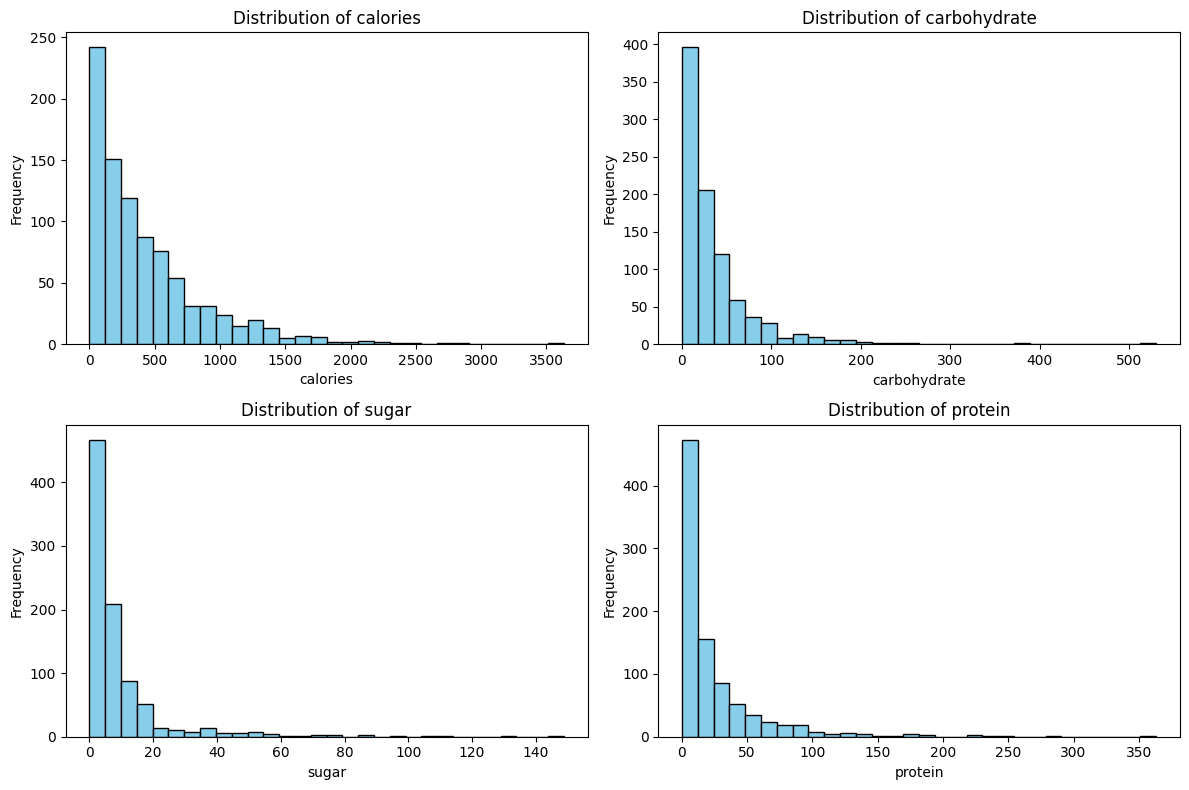

In [128]:
features = ['calories', 'carbohydrate', 'sugar', 'protein']
plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    plt.hist(recipe_site_traffic_2212[feature].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [129]:
skewness_values = recipe_site_traffic_2212[['calories', 'carbohydrate', 'sugar', 'protein']].skew()
print(skewness_values)

calories        2.036151
carbohydrate    3.756980
sugar           4.223352
protein         3.509453
dtype: float64


In [130]:
mean_values = recipe_site_traffic_2212[['calories', 'carbohydrate', 'sugar', 'protein']].mean()
median_values = recipe_site_traffic_2212[['calories', 'carbohydrate', 'sugar', 'protein']].median()
print("Mean Values:\n", mean_values)
print("\nMedian Values:\n", median_values)

Mean Values:
 calories        435.939196
carbohydrate     35.069676
sugar             9.046547
protein          24.149296
dtype: float64

Median Values:
 calories        288.55
carbohydrate     21.48
sugar             4.55
protein          10.80
dtype: float64


In [131]:
recipe_site_traffic_2212['calories'] = recipe_site_traffic_2212['calories'].fillna(recipe_site_traffic_2212['calories'].median())
recipe_site_traffic_2212['carbohydrate'] = recipe_site_traffic_2212['carbohydrate'].fillna(recipe_site_traffic_2212['carbohydrate'].median())
recipe_site_traffic_2212['sugar'] = recipe_site_traffic_2212['sugar'].fillna(recipe_site_traffic_2212['sugar'].median())
recipe_site_traffic_2212['protein'] = recipe_site_traffic_2212['protein'].fillna(recipe_site_traffic_2212['protein'].median())

In [132]:
print(recipe_site_traffic_2212.high_traffic.value_counts(), '\n', recipe_site_traffic_2212.high_traffic.isna().sum())

high_traffic
High    574
Name: count, dtype: int64 
 373


574 values are high, the missing 373 are otherwise low as descibed in the data dictionary 

In [133]:
recipe_site_traffic_2212['high_traffic'] = recipe_site_traffic_2212['high_traffic'].fillna('Low')

In [134]:
recipe_site_traffic_2212.high_traffic.value_counts()

high_traffic
High    574
Low     373
Name: count, dtype: int64

from above, the null are assigned to 'Low'.

In [135]:
recipe_site_traffic_2212.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,288.55,21.48,4.55,10.80,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,Low
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,Low


In [136]:
recipe_site_traffic_2212.isna().sum()

recipe          0
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64

*no missing data hence a clean data.*

In [137]:
recipe_site_traffic_2212.servings.unique()

array(['6', '4', '1', '2', '4 as a snack', '6 as a snack'], dtype=object)

In [138]:
recipe_site_traffic_2212.servings = recipe_site_traffic_2212.servings.astype(str)

In [139]:
recipe_site_traffic_2212.servings = recipe_site_traffic_2212.servings.str.replace(' as a snack', '')

In [140]:
recipe_site_traffic_2212.servings.unique()

array(['6', '4', '1', '2'], dtype=object)

In [141]:
recipe_site_traffic_2212.servings = recipe_site_traffic_2212['servings'].astype('int64')

In [142]:
recipe_site_traffic_2212.category.unique()

array(['Pork', 'Potato', 'Breakfast', 'Beverages', 'One Dish Meal',
       'Chicken Breast', 'Lunch/Snacks', 'Chicken', 'Vegetable', 'Meat',
       'Dessert'], dtype=object)

In [143]:
recipe_site_traffic_2212.category = recipe_site_traffic_2212.category.str.replace('Chicken Breast', 'Chicken')

In [144]:
recipe_site_traffic_2212.category.unique()

array(['Pork', 'Potato', 'Breakfast', 'Beverages', 'One Dish Meal',
       'Chicken', 'Lunch/Snacks', 'Vegetable', 'Meat', 'Dessert'],
      dtype=object)

In [145]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [146]:
ordinal_encoder = OrdinalEncoder(categories=[['Low', 'High']])

In [147]:
recipe_site_traffic_2212['high_traffic_transf'] = ordinal_encoder.fit_transform(recipe_site_traffic_2212[['high_traffic']])

In [148]:
recipe_site_traffic_2212['high_traffic_transf'] = recipe_site_traffic_2212['high_traffic_transf'].astype(int)

## Data Validation
- recipe: No missing value, sequential integers. column used for recipe indexing only.
- calories: 52 null values, floating point numeric data, rightly skewed, imputed with the median. it will be scaled before fitting into models.           
- carbohydrate: same operation as the calories feature.
- sugar: same operation as the calories feature.
- protein: same operation as the calories feature.
- category: non null, categorical feature. The 'Chicken Breast' category converted to 'Chicken' as directed. The feature will be transformed to numeric values for the classification model development using the onehot encoding.
- serving: non null, numeric data originally but posessing the object datatype. the datatype was transformed to integer.
- high_traffic: 373 null were inputed as 'low' as described in the data. Target value of classification model, it to be transformed by the label encoder into numeric integer as required by the classification models

## Exploratory Data Analysis

In [149]:
corr_ = recipe_site_traffic_2212[['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'high_traffic_transf']].corr()

<Axes: >

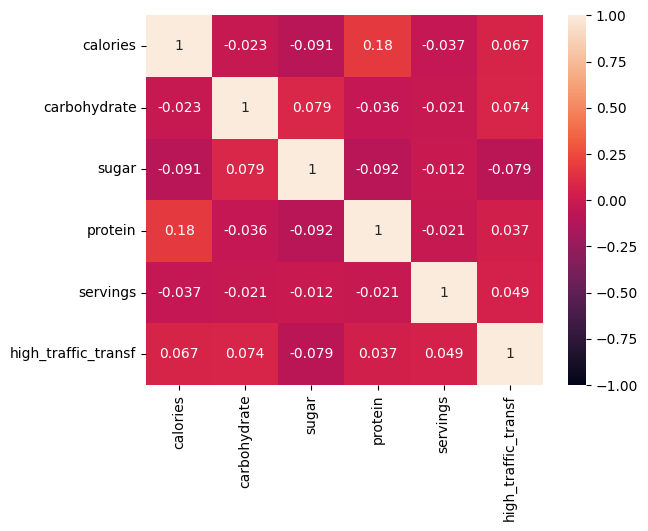

In [150]:
sns.heatmap(corr_, annot=True, vmin = -1, vmax = 1)

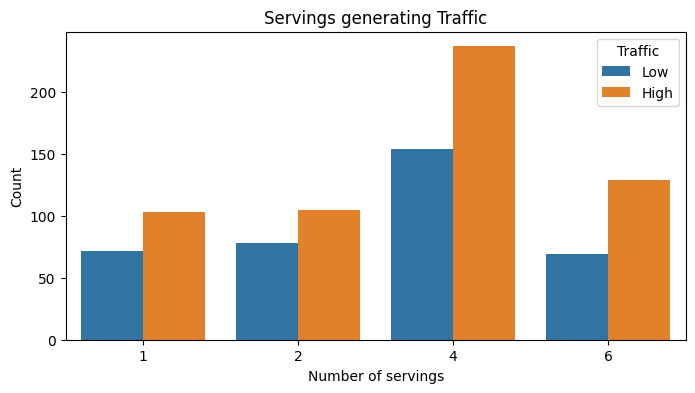

In [151]:
plt.figure(figsize=(8, 4))
sns.countplot(x='servings', hue='high_traffic', data= recipe_site_traffic_2212)
plt.title('Servings generating Traffic')
plt.xlabel('Number of servings')
plt.ylabel('Count')
plt.legend(title='Traffic')
plt.show()

In [152]:
high_traffic_cat_high = recipe_site_traffic_2212[recipe_site_traffic_2212['high_traffic']== 'High']['category']
high_traffic_cat_low = recipe_site_traffic_2212[recipe_site_traffic_2212['high_traffic']== 'Low']['category']

In [153]:
high_traf_cat_high = high_traffic_cat_high.value_counts()
high_traf_cat_low = high_traffic_cat_low.value_counts()

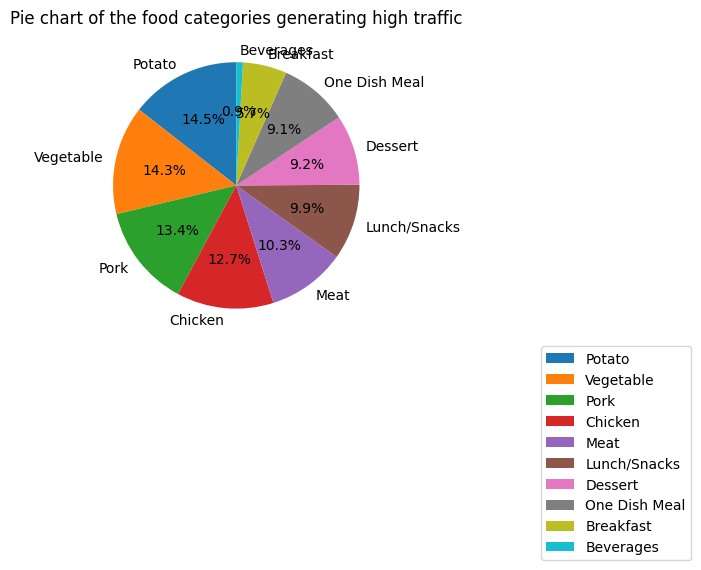

In [154]:
plt.figure(figsize=(8,4))
plt.pie(high_traf_cat_high, labels=high_traf_cat_high.index, autopct='%1.1f%%', startangle=90)
plt.title('Pie chart of the food categories generating high traffic')
plt.legend(bbox_to_anchor = (2, 0))
plt.show()

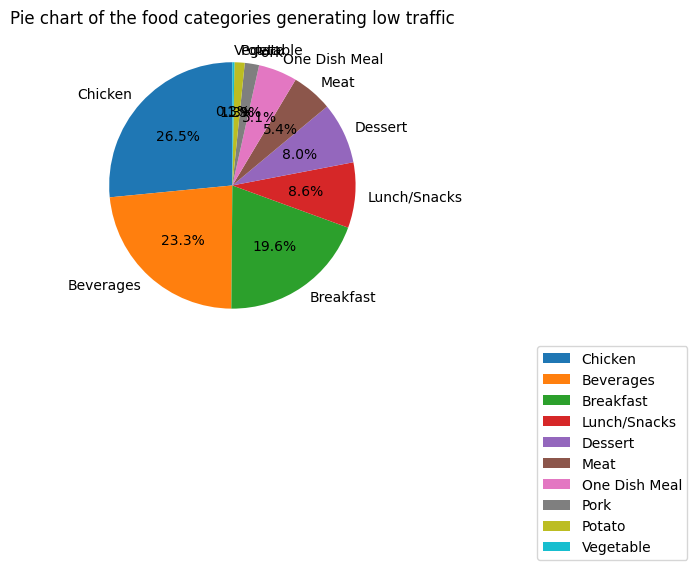

In [155]:
plt.figure(figsize=(8,4))
plt.pie(high_traf_cat_low, labels=high_traf_cat_low.index, autopct='%1.1f%%', startangle=90)
plt.title('Pie chart of the food categories generating low traffic')
plt.legend(bbox_to_anchor = (2, 0))
plt.show()

### Findings
- From the correlation heatmap, it is obvious that the nutrient features and number of servings of a recipe do not affects its traffic on the website.
  
- From the countpolt, we can conclude that the recipe with servings of 4 were mostly uploaded, over 40% the entire time. Simulteanously, the servings of 4 generated more traffic distinctly.

- From the pie charts, the food categories generating the traffic are potato, vegetable, pork and chicken totalling over 50% of the total traffic. Meanwhile chicken, beverages, breakfast and Lunch/snacks are associated with the low traffic, accounting for almost 75% of the low traffic the entire time.`

## Model Development
- This task is classification task. It means predicting an outcome out of 2 or more possible outcomes. To predict if a recipe will generate traffic or not, on the website.
- The logistic regression will be employed as the base model.
- The random forest classifier will be used as the alternative model for comparison

In [156]:
recipe_site_traffic_2212.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic,high_traffic_transf
0,1,288.55,21.48,4.55,10.80,Pork,6,High,1
1,2,35.48,38.56,0.66,0.92,Potato,4,High,1
2,3,914.28,42.68,3.09,2.88,Breakfast,1,Low,0
3,4,97.03,30.56,38.63,0.02,Beverages,4,High,1
4,5,27.05,1.85,0.80,0.53,Beverages,4,Low,0


In [157]:
recipe_site_traffic_2212.dtypes

recipe                   int64
calories               float64
carbohydrate           float64
sugar                  float64
protein                float64
category                object
servings                 int64
high_traffic            object
high_traffic_transf      int64
dtype: object

In [158]:
cat_dummy = pd.get_dummies(recipe_site_traffic_2212['category'], prefix= 'cat', prefix_sep='_',
                           sparse = False, dtype=int)

In [159]:
cat_dummy.head()

,cat_Beverages,cat_Breakfast,cat_Chicken,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable
0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0


In [160]:
combined_df = pd.concat([recipe_site_traffic_2212, cat_dummy], axis =1)

In [161]:
combined_df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic,high_traffic_transf,cat_Beverages,cat_Breakfast,cat_Chicken,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable
0,1,288.55,21.48,4.55,10.80,Pork,6,High,1,0,0,0,0,0,0,0,1,0,0
1,2,35.48,38.56,0.66,0.92,Potato,4,High,1,0,0,0,0,0,0,0,0,1,0
2,3,914.28,42.68,3.09,2.88,Breakfast,1,Low,0,0,1,0,0,0,0,0,0,0,0
3,4,97.03,30.56,38.63,0.02,Beverages,4,High,1,1,0,0,0,0,0,0,0,0,0
4,5,27.05,1.85,0.80,0.53,Beverages,4,Low,0,1,0,0,0,0,0,0,0,0,0


In [162]:
from sklearn.preprocessing import StandardScaler

In [163]:
scaler = StandardScaler()
features_to_scale = ['calories', 'carbohydrate', 'sugar', 'protein']
combined_df[features_to_scale] = scaler.fit_transform(combined_df[features_to_scale])

In [164]:
combined_df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic,high_traffic_transf,cat_Beverages,cat_Breakfast,cat_Chicken,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable
0,1,-0.315549,-0.299986,-0.297194,-0.355709,Pork,6,High,1,0,0,0,0,0,0,0,1,0,0
1,2,-0.888831,0.098953,-0.569236,-0.634271,Potato,4,High,1,0,0,0,0,0,0,0,0,1,0
2,3,1.101925,0.195184,-0.399297,-0.579009,Breakfast,1,Low,0,0,1,0,0,0,0,0,0,0,0
3,4,-0.749401,-0.087904,2.086151,-0.659646,Beverages,4,High,1,1,0,0,0,0,0,0,0,0,0
4,5,-0.907928,-0.758485,-0.559446,-0.645266,Beverages,4,Low,0,1,0,0,0,0,0,0,0,0,0


In [165]:
print(len(combined_df), '\n', combined_df.columns)

947 
 Index(['recipe', 'calories', 'carbohydrate', 'sugar', 'protein', 'category',
       'servings', 'high_traffic', 'high_traffic_transf', 'cat_Beverages',
       'cat_Breakfast', 'cat_Chicken', 'cat_Dessert', 'cat_Lunch/Snacks',
       'cat_Meat', 'cat_One Dish Meal', 'cat_Pork', 'cat_Potato',
       'cat_Vegetable'],
      dtype='object')


In [166]:
X = combined_df[['calories', 'carbohydrate', 'sugar', 'protein',
       'servings', 'cat_Beverages', 'cat_Breakfast', 'cat_Chicken', 'cat_Dessert',
       'cat_Lunch/Snacks', 'cat_Meat', 'cat_One Dish Meal', 'cat_Pork', 'cat_Potato', 'cat_Vegetable']]
y = combined_df['high_traffic_transf']

In [167]:
print(len(X), len(y), '\n', X.dtypes, '\n', y.dtypes)

947 947 
 calories             float64
carbohydrate         float64
sugar                float64
protein              float64
servings               int64
cat_Beverages          int64
cat_Breakfast          int64
cat_Chicken            int64
cat_Dessert            int64
cat_Lunch/Snacks       int64
cat_Meat               int64
cat_One Dish Meal      int64
cat_Pork               int64
cat_Potato             int64
cat_Vegetable          int64
dtype: object 
 int64


In [168]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, precision_score

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= .2, random_state=12)

In [170]:
log = LogisticRegression()
log.fit(X_train, y_train.values)
log_pred = log.predict(X_test)
print(confusion_matrix(y_test, log_pred))
print('logistic f1_score', round(f1_score(y_test, log_pred), 3))
print('logistic roc auc score', round(roc_auc_score(y_test, log_pred), 3))
print('logistic_precision', round(precision_score(y_test, log_pred), 3))

[[52 19]
 [24 95]]
logistic f1_score 0.815
logistic roc auc score 0.765
logistic_precision 0.833


In [171]:
precisions = []
f1_scores = []
roc_aucs = []
for i in range(10):
    log_rg = LogisticRegression(solver= 'liblinear',max_iter = i)
    log_rg.fit(X_train, y_train.values)
    log_pred = log_rg.predict(X_test)
    precisions.append(round(precision_score(y_test, log_pred), 3))
    f1_scores.append(round(f1_score(y_test, log_pred), 3))
    roc_aucs.append(round(roc_auc_score(y_test, log_pred), 3))
    print(confusion_matrix(y_test, log_pred), '\n')

[[ 71   0]
 [119   0]] 



/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/sv

[[53 18]
 [22 97]] 

[[52 19]
 [25 94]] 

[[52 19]
 [24 95]] 

[[52 19]
 [24 95]] 

[[52 19]
 [24 95]] 



/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[[52 19]
 [24 95]] 

[[52 19]
 [24 95]] 

[[52 19]
 [24 95]] 

[[52 19]
 [24 95]] 



In [172]:
print(precisions, '\t', f1_scores, '\t', roc_aucs)

[0.0, 0.843, 0.832, 0.833, 0.833, 0.833, 0.833, 0.833, 0.833, 0.833] 	 [0.0, 0.829, 0.81, 0.815, 0.815, 0.815, 0.815, 0.815, 0.815, 0.815] 	 [0.5, 0.781, 0.761, 0.765, 0.765, 0.765, 0.765, 0.765, 0.765, 0.765]


In [173]:
forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train.values)
forest_pred = forest_model.predict(X_test)
print(confusion_matrix(y_test, forest_pred))
print('random forest f1_score', round(f1_score(y_test, forest_pred), 3))
print('random forest roc auc score', round(roc_auc_score(y_test, forest_pred), 3))
print('random forest precision', round(precision_score(y_test, forest_pred), 3))

[[51 20]
 [24 95]]
random forest f1_score 0.812
random forest roc auc score 0.758
random forest precision 0.826


In [174]:
forest_precisions = []
forest_f1_scores = []
forest_roc_aucs = []
for i in range(10, 200, 20):
    forest_classifier = RandomForestClassifier(n_estimators= i, random_state= 12)
    forest_classifier.fit(X_train, y_train.values)
    forest_pred = forest_classifier.predict(X_test)
    forest_precisions.append(round(precision_score(y_test, forest_pred), 3))
    forest_f1_scores.append(round(f1_score(y_test, forest_pred), 3))
    forest_roc_aucs.append(round(roc_auc_score(y_test, forest_pred), 3))
    print(confusion_matrix(y_test, forest_pred), '\n')

[[55 16]
 [31 88]] 

[[51 20]
 [27 92]] 

[[53 18]
 [28 91]] 

[[53 18]
 [28 91]] 

[[54 17]
 [25 94]] 

[[52 19]
 [24 95]] 

[[51 20]
 [24 95]] 

[[52 19]
 [24 95]] 

[[51 20]
 [25 94]] 

[[51 20]
 [25 94]] 



In [175]:
print(forest_precisions, '\t', forest_f1_scores, '\t', forest_roc_aucs)

[0.846, 0.821, 0.835, 0.835, 0.847, 0.833, 0.826, 0.833, 0.825, 0.825] 	 [0.789, 0.797, 0.798, 0.798, 0.817, 0.815, 0.812, 0.815, 0.807, 0.807] 	 [0.757, 0.746, 0.756, 0.756, 0.775, 0.765, 0.758, 0.765, 0.754, 0.754]


## Model Evaluation
- The logistic regression model with max_iter parameter of 1 generated the best result amongst its parameter-tuned counterparts, hence it adoption for comparison.
- The random forest with n_estimator paramenter of 90 yielded the best precision amongst its parameter-tuned counterparts. Hence its adoption too

In [176]:
from sklearn.metrics import roc_curve, auc

In [181]:
log = LogisticRegression(solver='liblinear', max_iter=1)
log.fit(X_train, y_train.values)
log_pred = log.predict(X_test)
print(confusion_matrix(y_test, log_pred))
print('logistic f1_score', round(f1_score(y_test, log_pred), 3))
print('logistic roc auc score', round(roc_auc_score(y_test, log_pred), 3))
print('logistic_precision', round(precision_score(y_test, log_pred), 3))
log_fpr, log_tpr, _ = roc_curve(y_test, log_pred)
log_roc_auc = auc(log_fpr, log_tpr)

[[53 18]
 [22 97]]
logistic f1_score 0.829
logistic roc auc score 0.781
logistic_precision 0.843


/home/abdullahimujaheed/mypyenv/work/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


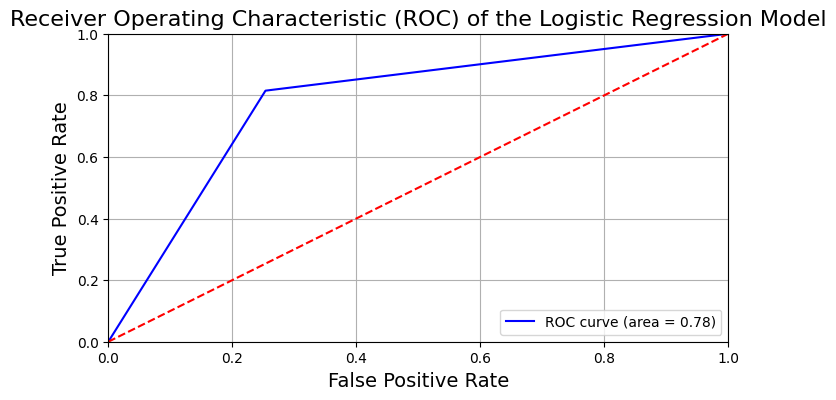

In [182]:
#Plotting ROC curve
plt.figure(figsize=(8, 4))
plt.plot(log_fpr, log_tpr, color='blue', label='ROC curve (area = %0.2f)' % log_roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) of the Logistic Regression Model', fontsize=16)
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [179]:
forest_model_best = RandomForestClassifier(n_estimators=90, random_state=12)
forest_model_best.fit(X_train, y_train.values)
forest_pred_best = forest_model_best.predict(X_test)
print(confusion_matrix(y_test, forest_pred_best))
print('random forest f1_score', round(f1_score(y_test, forest_pred_best), 3))
print('random forest roc auc score', round(roc_auc_score(y_test, forest_pred_best), 3))
print('random forest precision', round(precision_score(y_test, forest_pred_best), 3))
fpr_forest, tpr_forest, _ = roc_curve(y_test, forest_pred_best)
roc_auc = auc(fpr_forest, tpr_forest)

[[54 17]
 [25 94]]
random forest f1_score 0.817
random forest roc auc score 0.775
random forest precision 0.847


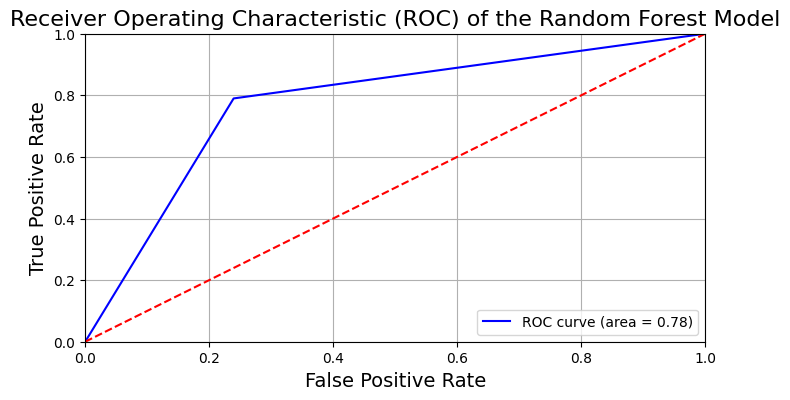

In [180]:
# Plotting ROC curve
plt.figure(figsize=(8, 4))
plt.plot(fpr_forest, tpr_forest, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) of the Random Forest Model', fontsize=16)
plt.legend(loc='lower right')
plt.grid()
plt.show()

### Model Evaluation findings
The Logistic Regression outperforms the Random Forest Classifier on f1 score and roc_auc scores, while the random forest classifier has better precision metric. Most notably, the ROC-AUC curve score of both models is 0.78 indicating that both models have good discriminative ability, distinguishing between high and low traffic generating recipes.

## Business Metric
- The product team's primary goal is to "predict which recipes will lead to high traffic also minimize the chance of showing unpopular recipes." This emphasis on avoiding unpopular recipe recommendations aligns with Precision as the key metric.  Recipes leading to high traffic are true positives while unpopular recipes classified as popular is a case of false positives, both which constitutes the precision score.
- The final precision score of 84.7% of the prediction while the initial high traffic of the original data 59.8%, meaning about 41% improvement and about 5% more than the desired precision from the product team.

## Final Summary and Recommendation
-  Although 80% precision was requested, the model delivers 84.7% precision, a significant 41% improvement over manual selection. This eliminates guesswork and provides data-driven recommendations.

- I recommend the deplyment of the logistic regression model while adhering to monitoring during and after the deployment. 
- I recommend collection of additional data for the accomodation of more sophisticated model without the fear of overfitting.

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation